# **Pemetaan Mangrove Menggunakan Random Forest**

---
**oleh : Defani Arman Alfitriansyah**

<div align="left">
  <a href="https://linkedin.com/in/defaniarmanalfitriansyah"><img src="https://img.shields.io/badge/LinkedIn-0077B5?style=flat-square&logo=linkedin&logoColor=white" alt="LinkedIn" /></a>
  <a href="https://medium.com/@defaniarman"><img src="https://img.shields.io/badge/Medium-12100E?style=flat-square&logo=medium&logoColor=white" alt="Medium" /></a>
  <a href="https://tiktok.com/@defaniarman"><img src="https://img.shields.io/badge/TikTok-000000?style=flat-square&logo=tiktok&logoColor=white" alt="TikTok" /></a>
  <a href="https://www.instagram.com/de.fanii"><img src="https://img.shields.io/badge/Instagram-E4405F?style=flat-square&logo=instagram&logoColor=white" alt="Instagram" /></a>
  <a href="https://www.kaggle.com/defani123"><img src="https://img.shields.io/badge/Kaggle-20BEFF?style=flat-square&logo=kaggle&logoColor=white" alt="Kaggle" /></a>
  <a href="https://rpubs.com/defanii"><img src="https://img.shields.io/badge/RPubs-75AADB?style=flat-square&logo=r&logoColor=white" alt="RPubs" /></a>
  <a href="https://www.behance.net/defaniarman"><img src="https://img.shields.io/badge/Behance-1769FF?style=flat-square&logo=behance&logoColor=white" alt="Behance" /></a>
  <a href="mailto:defaniarman@gmail.com"><img src="https://img.shields.io/badge/Email-D14836?style=flat-square&logo=gmail&logoColor=white" alt="Email" /></a>
  <a href="https://github.com/Defani"><img src="https://img.shields.io/badge/GitHub-100000?style=flat-square&logo=github&logoColor=white" alt="GitHub" /></a>
</div>


---

In [1]:
#NGINSTALL LIBRARY
!pip install earthengine-api geemap cartopy matplotlib numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.1 MB/s eta 0:00:00


In [2]:
# IMPORT LIBRARY
import ee
import geemap.cartoee as cartoee
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.geoaxes import GeoAxes
import numpy as np
import pandas as pd
import seaborn as sns
import geemap
import warnings
warnings.filterwarnings('ignore')

# FIX CARTOEE COMPATIBILITY
cartoee.GeoAxes = GeoAxes
cartoee.GeoAxesSubplot = GeoAxes
cartoee.ccrs = ccrs

# INIT GEE
ee.Authenticate()
ee.Initialize(project='ee-defaniarman')

In [3]:
# LOAD ASSETS
batas_kajian = ee.FeatureCollection('projects/ee-defaniarman/assets/sample/batas_kajian')
sampel_titik = ee.FeatureCollection('projects/ee-defaniarman/assets/sample/sampel_titik')

# DEFINE BANDS & INDICES
bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
indices = ['NDVI', 'NDWI', 'NDMI', 'NDBI', 'IRECI']
all_bands = bands + indices

# DEFINE CLOUD SCORE+
csPlus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')

# CLOUD MASK FUNCTION
def maskS2CSPlus(image):
    qa = image.select('cs_cdf')
    return image.updateMask(qa.gte(0.60))

# PREPROCESS S2
s2_base = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(batas_kajian)
    .filterDate('2024-01-01', '2025-12-10')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

s2 = (s2_base
    .linkCollection(csPlus, ['cs_cdf'])
    .map(maskS2CSPlus)
    .median()
    .clip(batas_kajian)
    .divide(10000))

# ADD INDICES
ndvi = s2.select('B8').subtract(s2.select('B4')).divide(s2.select('B8').add(s2.select('B4'))).rename('NDVI')
ndwi = s2.select('B3').subtract(s2.select('B8')).divide(s2.select('B3').add(s2.select('B8'))).rename('NDWI')
ndmi = s2.select('B8').subtract(s2.select('B11')).divide(s2.select('B8').add(s2.select('B11'))).rename('NDMI')
ndbi = s2.select('B11').subtract(s2.select('B8')).divide(s2.select('B11').add(s2.select('B8'))).rename('NDBI')
ireci = s2.select('B8').subtract(s2.select('B4')).divide(s2.select('B5').divide(s2.select('B6'))).rename('IRECI')

image_with_indices = s2.addBands([ndvi, ndwi, ndmi, ndbi, ireci])

# EXTRACT BAND VALUES TO POINTS (KARENA PAKE SAMPEL TITIK)
print("EXTRACTING REFLECTANCE DATA...")
training_data = image_with_indices.select(all_bands).sampleRegions(
    collection=sampel_titik,
    properties=['lc'],
    scale=10
)

# TRAIN MODEL
print("TRAINING RANDOM FOREST...")
classifier = ee.Classifier.smileRandomForest(500).train(
    features=training_data,
    classProperty='lc',
    inputProperties=all_bands
)

# CLASSIFY IMAGE
classified_image = image_with_indices.select(all_bands).classify(classifier)

# GET BOUNDING BOX
region = batas_kajian.geometry().bounds().getInfo()['coordinates'][0]
bbox = [region[0][0], region[0][1], region[2][0], region[2][1]]



EXTRACTING REFLECTANCE DATA...
TRAINING RANDOM FOREST...


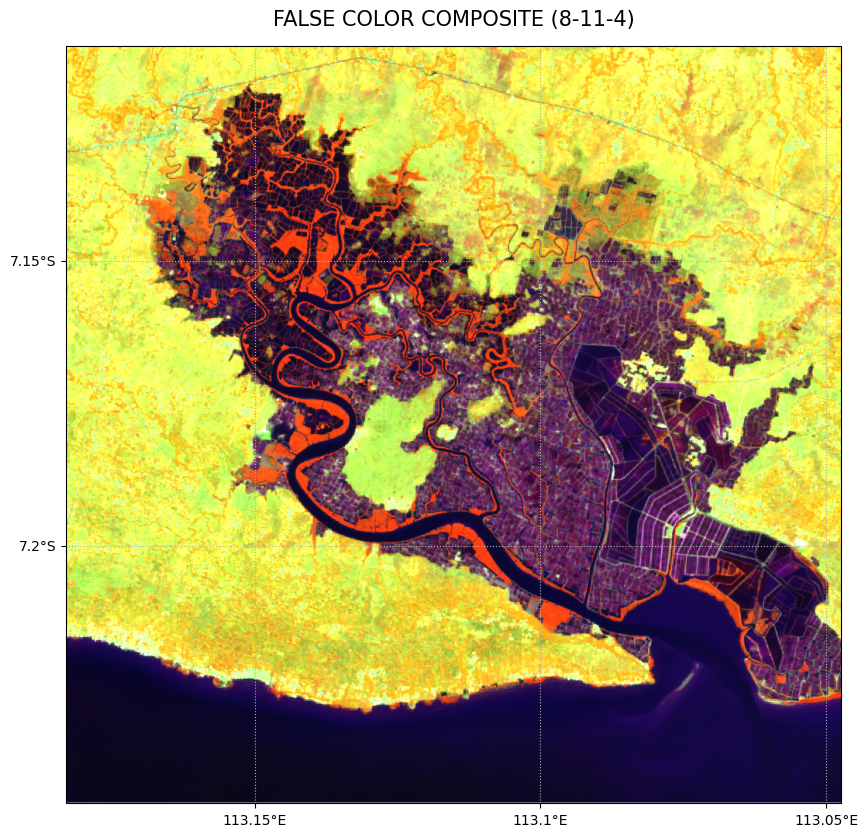

In [4]:
# PLOT COMPOSITE
fig = plt.figure(figsize=(10, 10))

ax = cartoee.get_map(s2, region=bbox, vis_params={'bands': ['B8', 'B11', 'B4'], 'min': 0, 'max': 0.3})
cartoee.add_gridlines(ax, interval=0.05, linestyle=":")
ax.set_title(label='FALSE COLOR COMPOSITE (8-11-4)', fontsize=15, pad=15)

plt.show()

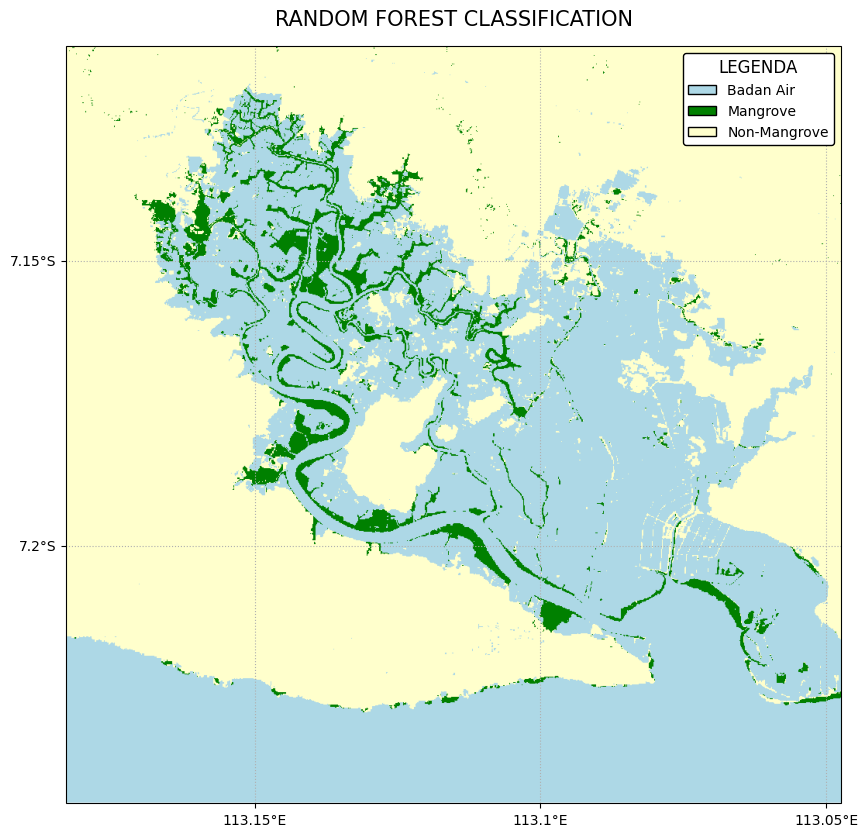

In [5]:
# PLOT CLASSIFICATION
fig = plt.figure(figsize=(10, 10))

# SET PALETTE & LABELS
palette_gee = ['lightblue', 'green', 'ffffcc']
labels = ['Badan Air', 'Mangrove', 'Non-Mangrove']

ax = cartoee.get_map(classified_image, region=bbox, vis_params={'min': 0, 'max': 2, 'palette': palette_gee})
cartoee.add_gridlines(ax, interval=0.05, linestyle=":")
ax.set_title(label='RANDOM FOREST CLASSIFICATION', fontsize=15, pad=15)

# ADD CUSTOM LEGEND
legend_colors = ['#add8e6', '#008000', '#ffffcc']
legend_elements = [mpatches.Patch(color=legend_colors[i], label=labels[i], ec='black') for i in range(3)]
ax.legend(handles=legend_elements, loc='upper right', facecolor='white', framealpha=1,
          edgecolor='black', title="LEGENDA", fontsize=10, title_fontsize=12)

plt.show()

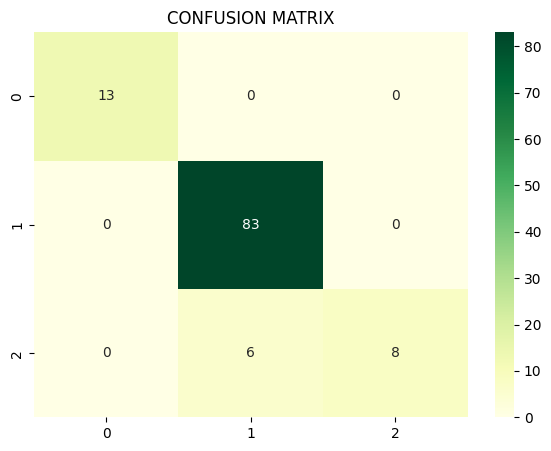

OVERALL ACCURACY: 0.9455
KAPPA COEFFICIENT: 0.8511


In [6]:
# SPLIT DATA 70:30
split_data = training_data.randomColumn()
train_set = split_data.filter(ee.Filter.lt('random', 0.7))
test_set = split_data.filter(ee.Filter.gte('random', 0.7))

# TRAIN FOR VALIDATION
classifier_val = ee.Classifier.smileRandomForest(500).train(
    features=train_set, classProperty='lc', inputProperties=all_bands
)
validated = test_set.classify(classifier_val)

# GET MATRIX
cm = validated.errorMatrix('lc', 'classification')
cm_array = np.array(cm.getInfo())

# PLOT DEFAULT MATRIX
plt.figure(figsize=(7, 5))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='YlGn')
plt.title('CONFUSION MATRIX')
plt.show()

# PRINT METRICS
print(f"OVERALL ACCURACY: {cm.accuracy().getInfo():.4f}")
print(f"KAPPA COEFFICIENT: {cm.kappa().getInfo():.4f}")

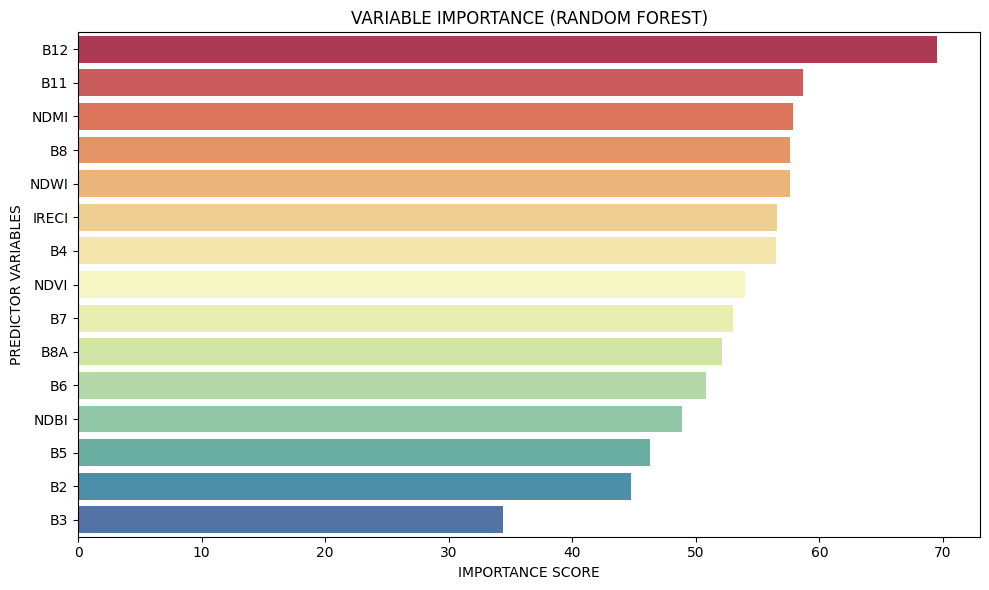

In [8]:
# GET VARIABLE IMPORTANCE FROM RANDOM FOREST
dict_importance = classifier.explain().get('importance').getInfo()

# CONVERT TO DATAFRAME AND SORT
df_importance = pd.DataFrame(
    list(dict_importance.items()),
    columns=['VARIABLE', 'IMPORTANCE']
).sort_values(by='IMPORTANCE', ascending=False)

# PLOT IMPORTANCE
plt.figure(figsize=(10, 6))
sns.barplot(x='IMPORTANCE', y='VARIABLE', data=df_importance, palette='Spectral')
plt.title('VARIABLE IMPORTANCE (RANDOM FOREST)')
plt.xlabel('IMPORTANCE SCORE')
plt.ylabel('PREDICTOR VARIABLES')
plt.tight_layout()
plt.show()

```markdown
## Correlation Heatmap

To understand the relationship between the input variables (bands and indices) and the target classes, we can generate a correlation heatmap. This helps in identifying which variables have a stronger influence on distinguishing between the different land cover types.
```

In [12]:
# Extract training data to a pandas DataFrame
print("Converting training data to pandas DataFrame...")

# Get the list of properties to extract from each feature
# This includes all bands/indices and the 'lc' class property
properties_to_extract = all_bands + ['lc']

# Map over the feature collection to extract properties as a list of dictionaries
list_of_dicts = training_data.map(lambda feature: feature.select(properties_to_extract)).getInfo()

# Extract only the 'properties' dictionary from each item in the list
# The actual features are under the 'features' key when getInfo() is called on a FeatureCollection
data_for_df = [item['properties'] for item in list_of_dicts['features']]

df_train = pd.DataFrame(data_for_df)
display(df_train.head())

Converting training data to pandas DataFrame...


,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,IRECI,NDBI,NDMI,NDVI,NDWI,lc
0,0.00600,0.00595,0.07865,0.10500,0.05345,0.03855,0.01310,0.01380,0.01025,0.00825,-0.014680,-0.261538,0.261538,-0.678179,0.822126,0
1,0.00590,0.00555,0.07810,0.09975,0.04760,0.04015,0.01405,0.01485,0.00970,0.00940,-0.013263,-0.243590,0.243590,-0.661431,0.822750,0
2,0.00735,0.00655,0.07930,0.11200,0.09195,0.08635,0.03075,0.03300,0.02630,0.01825,-0.023379,-0.563150,0.563150,-0.555180,0.619667,0
3,0.00755,0.00605,0.08190,0.11540,0.08850,0.08155,0.03165,0.03410,0.02640,0.01870,-0.024101,-0.555228,0.555228,-0.540470,0.627645,0
4,0.00920,0.00740,0.08160,0.11780,0.08670,0.07760,0.03180,0.03340,0.02570,0.02200,-0.024997,-0.472779,0.472779,-0.542705,0.641812,0


,Correlation with Class
B11,0.813925
B6,0.722195
B8,0.717797
B8A,0.714803
B7,0.705169
B12,0.685460
NDVI,0.682008
B5,0.615666
IRECI,0.459248
NDBI,0.093500


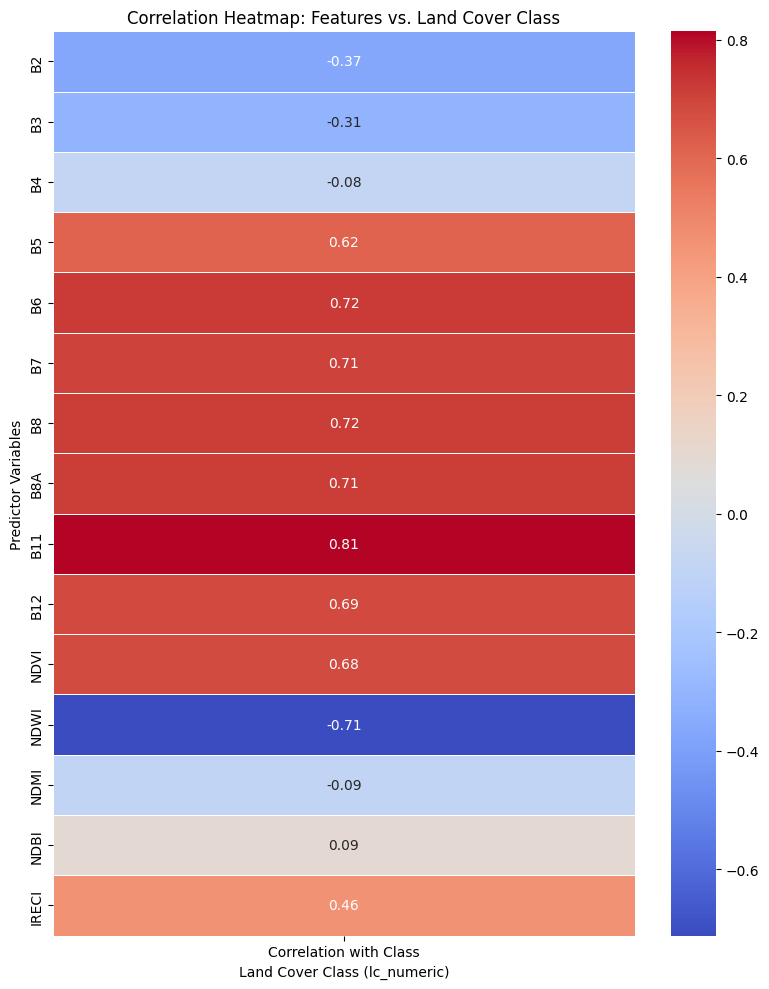

In [13]:
# Calculate the correlation matrix
# We're interested in the correlation of each band/index with the 'lc' (land cover) class
# Convert 'lc' to a numeric type if it's not already, for correlation calculation
df_train['lc_numeric'] = df_train['lc'].astype(int)

# Select only the columns for correlation (all_bands + lc_numeric)
correlation_columns = all_bands + ['lc_numeric']

# Calculate the correlation matrix
corr_matrix = df_train[correlation_columns].corr()

# Extract correlations of features with the 'lc_numeric' class
# We take the absolute value to see the strength of the relationship, regardless of direction
feature_class_corr = corr_matrix.loc[all_bands, 'lc_numeric'].to_frame()
feature_class_corr.columns = ['Correlation with Class']

display(feature_class_corr.sort_values(by='Correlation with Class', ascending=False))

# Plot the correlation heatmap for the selected features against the class
plt.figure(figsize=(8, 10))
sns.heatmap(feature_class_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Features vs. Land Cover Class')
plt.xlabel('Land Cover Class (lc_numeric)')
plt.ylabel('Predictor Variables')
plt.tight_layout()
plt.show()

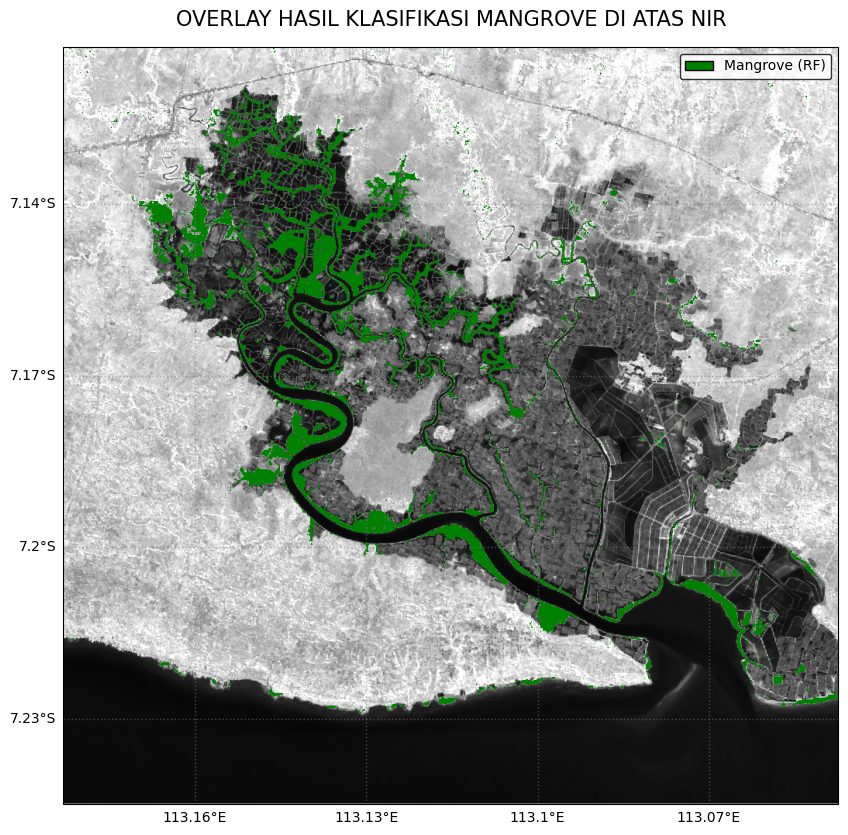

In [9]:
# MASKING KELAS MANGROVE DARI HASIL RF (KELAS = 1)
mangrove_mask = classified_image.eq(1)
mangrove_rf = mangrove_mask.updateMask(mangrove_mask)

# VISUALISASI & BLEND LANGSUNG DI GEE (MENCEGAH ERROR OVERLAY)
nir_vis = s2.select('B8').visualize(min=0, max=0.35, palette=['black', 'white'])
mangrove_vis = mangrove_rf.visualize(palette=['green'])
blended_image = nir_vis.blend(mangrove_vis)

# PLOT BLENDED MAP
fig = plt.figure(figsize=(10, 10))
ax = cartoee.get_map(blended_image, region=bbox)

# Calculate gridline locations based on bbox and interval
lon_min, lat_min, lon_max, lat_max = bbox
interval = 0.03
xlocs = np.arange(np.floor(lon_min / interval) * interval, np.ceil(lon_max / interval) * interval + interval / 2, interval)
ylocs = np.arange(np.floor(lat_min / interval) * interval, np.ceil(lat_max / interval) * interval + interval / 2, interval)

# TAMBAHKAN GRIDLINES & KOORDINAT LABELS
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  xlocs=xlocs, ylocs=ylocs,
                  linestyle=":", linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}

# SET JUDUL & LEGENDA
ax.set_title(label='OVERLAY HASIL KLASIFIKASI MANGROVE DI ATAS NIR', fontsize=15, pad=15)
legend_elements = [mpatches.Patch(color='green', label='Mangrove (RF)', ec='black')]
ax.legend(handles=legend_elements, loc='upper right', facecolor='white', edgecolor='black')

plt.show()